# Multi‑Agent Simulation Analysis – Complete & Memory‑Efficient

This notebook analyses **LivingAgent (mosquitoes)** and **InertAgent (water tanks)** from large snapshot CSV files (GB scale) on a laptop with 8 GB RAM.

**Memory‑saving strategies:**
- Daily aggregates computed incrementally (chunked CSV reading).
- Spatial analysis reads points **per tick** (never the whole file).
- For ticks with many points, we cap at 100 000 points (still enough for KDE and scatter).
- Geopandas basemap loaded once.

**Analyses included:**
- Population dynamics (adults, larvae, pupae over time)
- Water tank statistics (volume, eggs, larvae)
- Environmental correlation (configurable variables: temperature, precipitation, etc.)
- Temporal autocorrelation & cross‑correlation
- Spatial maps: adult heatmaps + tank locations, proximity over time, hotspot (LISA) map, tank occupancy heatmap
- Validation: Metzler matrix predicted growth rate vs observed
- Stage duration estimation (cross‑correlation of stage counts)
- Export of daily summary and a sample of raw data

## Configuration

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from scipy.spatial import cKDTree
from scipy.stats import pearsonr
from scipy.signal import correlate, correlation_lags
import os
import warnings
warnings.filterwarnings('ignore')

# ========== CONFIGURATION ==========
# --- EDIT THESE PATHS ---
INPUT_FILE = "/home/void/Documents/codes/monadvsim/results/merged_snapshots_20260421_020412.csv"
STUDY_AREA_FILE = "/home/void/Documents/codes/monadvsim/prepared_data/dire_dawa/dire_dawa.shp"
OUTPUT_DIR = "/mnt/monadworld/projects/phd/article_manuscripts/new/figs/"
# -------------------------
TICKS_PER_DAY = 96
CHUNKSIZE = 100000               # rows per chunk for daily aggregation
MAX_SPATIAL_POINTS_PER_TICK = 100000   # max points to read for a single tick (memory safe)
STAGE_COLORS = {'ADULT': '#2E8B57', 'LARVA': '#4169E1', 'PUPA': '#FF8C00'}

# ---- Environment variables to analyse (add/remove as needed) ----
# Each entry: (csv_column_name, display_name, unit, conversion_function, is_precipitation)
# NOTE: The CSV already stores temperature in Celsius (Java export converts from Kelvin).
# So we use identity conversion. For precipitation (if added later), convert metres to mm.
ENV_VARS = [
    ('t2m', 'Temperature', '°C', lambda x: x, False),      # CSV already Celsius
    # ('tp', 'Precipitation', 'mm', lambda x: x * 1000, True),   # uncomment when tp is available
]

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ========== LOAD STUDY AREA BASEMAP (once) ==========
if os.path.exists(STUDY_AREA_FILE):
    study_area = gpd.read_file(STUDY_AREA_FILE)
    if study_area.crs is None:
        study_area.crs = "EPSG:4326"
    elif study_area.crs.to_epsg() != 4326:
        study_area = study_area.to_crs("EPSG:4326")
    print(f"Loaded study area basemap: {STUDY_AREA_FILE}")
    print(f"Bounds (lon_min, lat_min, lon_max, lat_max): {study_area.total_bounds}")
else:
    print(f"Study area file not found: {STUDY_AREA_FILE}. Spatial plots will be without basemap.")
    study_area = None

# ========== DEFINE COLUMNS & DTYPES ==========
# Base columns that are always present
living_base_cols = ['TickCount', 'Stage', 'X', 'Y', 'AgentID', 'Age', 'Energy', 'Gravid']
# Add environment columns from config
env_col_names = [v[0] for v in ENV_VARS]
living_columns = living_base_cols + env_col_names
inert_columns = ['TickCount', 'X', 'Y', 'EggCount', 'LarvaCount', 'waterVolume', 'AgentID']

# Dtypes: environment columns as float32
living_dtypes = {
    'TickCount': 'int32',
    'Stage': 'category',
    'X': 'float32',
    'Y': 'float32',
    'AgentID': 'object',
    'Age': 'int16',
    'Energy': 'float32',
    'Gravid': 'int8'
}
for col in env_col_names:
    living_dtypes[col] = 'float32'

inert_dtypes = {
    'TickCount': 'int32',
    'X': 'float32',
    'Y': 'float32',
    'EggCount': 'int32',
    'LarvaCount': 'int32',
    'waterVolume': 'float32',
    'AgentID': 'object'
}

print(f"Environment variables: {env_col_names}")
print("Configuration ready.")

Loaded study area basemap: /home/void/Documents/codes/monadvsim/prepared_data/dire_dawa/dire_dawa.shp
Bounds (lon_min, lat_min, lon_max, lat_max): [41.72802774  9.47148374 42.3397728   9.78374168]
Environment variables: ['t2m']
Configuration ready.


## 1. Incremental Daily Aggregation (no full DataFrame stored)

Process the CSV chunk by chunk and compute daily totals for adults, larvae, pupae, mean environmental variables, and tank statistics.

In [12]:
def incremental_aggregation(filepath, living_cols, inert_cols, living_dtypes, inert_dtypes, 
                            env_vars, chunksize):
    """
    Process CSV in chunks, return daily aggregated data for living and inert agents.
    env_vars: list of (col_name, display_name, unit, conversion, is_precip)
    Returns:
        daily_living: DataFrame with Day, AdultCount, LarvaCount, PupaCount, and mean for each env var
        daily_inert: DataFrame with Day, TankCount, MeanWaterVolume, TotalEggs, TotalLarvae
    """
    # Accumulators
    daily_adults = {}
    daily_larvae = {}
    daily_pupae = {}
    # For each env var, store sum and count
    daily_env_sum = {col: {} for col, _, _, _, _ in env_vars}
    daily_env_cnt = {col: {} for col, _, _, _, _ in env_vars}
    
    daily_tank_count = {}
    daily_water_sum = {}
    daily_water_cnt = {}
    daily_eggs_sum = {}
    daily_larvae_sum = {}
    min_tick = None
    max_tick = None
    
    print("Starting chunked processing...")
    chunk_iter = pd.read_csv(filepath, chunksize=chunksize, low_memory=False)
    
    for i, chunk in enumerate(chunk_iter):
        if i % 10 == 0:
            print(f"Processing chunk {i}...")
        
        # Update tick range
        tick_min = chunk['TickCount'].min()
        tick_max = chunk['TickCount'].max()
        if min_tick is None or tick_min < min_tick:
            min_tick = tick_min
        if max_tick is None or tick_max > max_tick:
            max_tick = tick_max
        
        # Living agents
        living_mask = chunk['AgentType'] == 'LivingAgent'
        living_chunk = chunk.loc[living_mask, living_cols].astype(living_dtypes)
        if not living_chunk.empty:
            living_chunk['Day'] = (living_chunk['TickCount'] / TICKS_PER_DAY).astype('int32')
            # Stage counts
            adult = living_chunk[living_chunk['Stage'] == 'ADULT'].groupby('Day').size()
            larva = living_chunk[living_chunk['Stage'] == 'LARVA'].groupby('Day').size()
            pupa = living_chunk[living_chunk['Stage'] == 'PUPA'].groupby('Day').size()
            for day, cnt in adult.items():
                daily_adults[day] = daily_adults.get(day, 0) + cnt
            for day, cnt in larva.items():
                daily_larvae[day] = daily_larvae.get(day, 0) + cnt
            for day, cnt in pupa.items():
                daily_pupae[day] = daily_pupae.get(day, 0) + cnt
            
            # Environment variables
            for col, _, _, _, _ in env_vars:
                if col not in living_chunk.columns:
                    continue
                col_sum = living_chunk.groupby('Day')[col].sum()
                col_cnt = living_chunk.groupby('Day')[col].count()
                for day, val in col_sum.items():
                    daily_env_sum[col][day] = daily_env_sum[col].get(day, 0) + val
                    daily_env_cnt[col][day] = daily_env_cnt[col].get(day, 0) + col_cnt[day]
        
        # Inert agents (tanks)
        inert_mask = chunk['AgentType'] == 'InertAgent'
        inert_chunk = chunk.loc[inert_mask, inert_cols].astype(inert_dtypes)
        if not inert_chunk.empty:
            inert_chunk['Day'] = (inert_chunk['TickCount'] / TICKS_PER_DAY).astype('int32')
            tank_count = inert_chunk.groupby('Day')['AgentID'].nunique()
            water_sum = inert_chunk.groupby('Day')['waterVolume'].sum()
            water_cnt = inert_chunk.groupby('Day')['waterVolume'].count()
            eggs_sum = inert_chunk.groupby('Day')['EggCount'].sum()
            larvae_sum = inert_chunk.groupby('Day')['LarvaCount'].sum()
            for day, cnt in tank_count.items():
                daily_tank_count[day] = daily_tank_count.get(day, 0) + cnt
            for day, val in water_sum.items():
                daily_water_sum[day] = daily_water_sum.get(day, 0) + val
                daily_water_cnt[day] = daily_water_cnt.get(day, 0) + water_cnt[day]
            for day, val in eggs_sum.items():
                daily_eggs_sum[day] = daily_eggs_sum.get(day, 0) + val
            for day, val in larvae_sum.items():
                daily_larvae_sum[day] = daily_larvae_sum.get(day, 0) + val
    
    # Build daily DataFrames
    all_days = sorted(set(daily_adults.keys()) | set(daily_larvae.keys()) | set(daily_pupae.keys()) |
                      set().union(*[daily_env_sum[col].keys() for col in daily_env_sum]) |
                      set(daily_tank_count.keys()))
    
    daily_living_df = pd.DataFrame({'Day': all_days})
    daily_living_df['AdultCount'] = daily_living_df['Day'].map(daily_adults).fillna(0).astype('int32')
    daily_living_df['LarvaCount'] = daily_living_df['Day'].map(daily_larvae).fillna(0).astype('int32')
    daily_living_df['PupaCount'] = daily_living_df['Day'].map(daily_pupae).fillna(0).astype('int32')
    
    # Add environment variables (converted)
    for col, disp, unit, convert, is_precip in env_vars:
        mean_col = f'Mean{disp}'
        raw_mean = (daily_living_df['Day'].map(daily_env_sum[col]).fillna(0) /
                    daily_living_df['Day'].map(daily_env_cnt[col]).fillna(1))
        daily_living_df[mean_col] = convert(raw_mean).round(2 if not is_precip else 4)
    
    daily_inert_df = pd.DataFrame({'Day': all_days})
    daily_inert_df['TankCount'] = daily_inert_df['Day'].map(daily_tank_count).fillna(0).astype('int32')
    daily_inert_df['MeanWaterVolume'] = (daily_inert_df['Day'].map(daily_water_sum).fillna(0) /
                                         daily_inert_df['Day'].map(daily_water_cnt).fillna(1)).round(2)
    daily_inert_df['TotalEggs'] = daily_inert_df['Day'].map(daily_eggs_sum).fillna(0).astype('int64')
    daily_inert_df['TotalLarvae'] = daily_inert_df['Day'].map(daily_larvae_sum).fillna(0).astype('int64')
    
    print(f"Processed ticks {min_tick} to {max_tick}")
    return daily_living_df, daily_inert_df

daily_living, daily_inert = incremental_aggregation(
    INPUT_FILE, living_columns, inert_columns, living_dtypes, inert_dtypes, 
    ENV_VARS, CHUNKSIZE
)
print("\nDaily Living summary head:")
print(daily_living.head())
print("\nDaily Inert summary head:")
print(daily_inert.head())

Starting chunked processing...
Processing chunk 0...
Processing chunk 10...
Processing chunk 20...
Processing chunk 30...
Processing chunk 40...
Processing chunk 50...
Processing chunk 60...
Processing chunk 70...
Processing chunk 80...
Processing chunk 90...
Processing chunk 100...
Processing chunk 110...
Processed ticks 100 to 8600

Daily Living summary head:
   Day  AdultCount  LarvaCount  PupaCount  MeanTemperature
0    1      131237       54380      32855            27.40
1    2      130843       53591      33153            26.70
2    3      130517       52856      33338            26.83
3    4      129974       51766      33605            27.30
4    5      129409       50784      33741            27.23

Daily Inert summary head:
   Day  TankCount  MeanWaterVolume  TotalEggs  TotalLarvae
0    1       4694            85.19     208090       191526
1    2       4694            85.19     164694       234922
2    3       4694            85.19     127162       272454
3    4       4694  

## 2. Population Dynamics (Daily Aggregates)

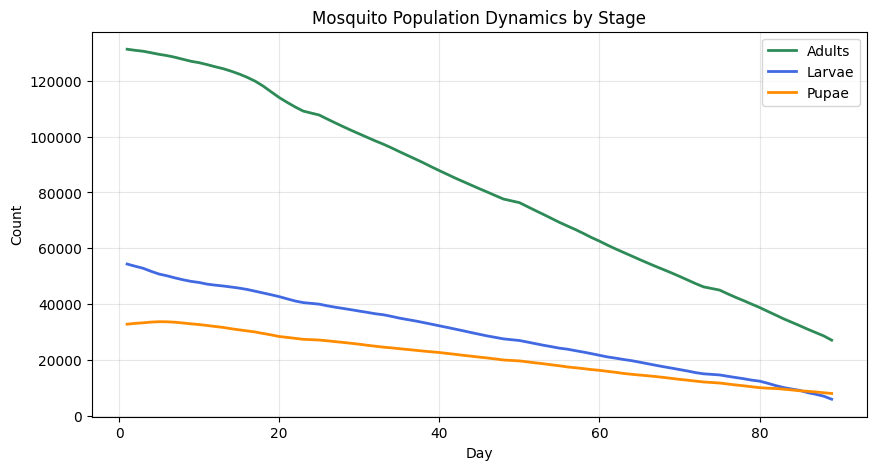

In [13]:
plt.figure(figsize=(10,5))
plt.plot(daily_living['Day'], daily_living['AdultCount'], label='Adults', color=STAGE_COLORS['ADULT'], linewidth=2)
plt.plot(daily_living['Day'], daily_living['LarvaCount'], label='Larvae', color=STAGE_COLORS['LARVA'], linewidth=2)
plt.plot(daily_living['Day'], daily_living['PupaCount'], label='Pupae', color=STAGE_COLORS['PUPA'], linewidth=2)
plt.xlabel('Day')
plt.ylabel('Count')
plt.title('Mosquito Population Dynamics by Stage')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/mosquito_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Water Tank Statistics

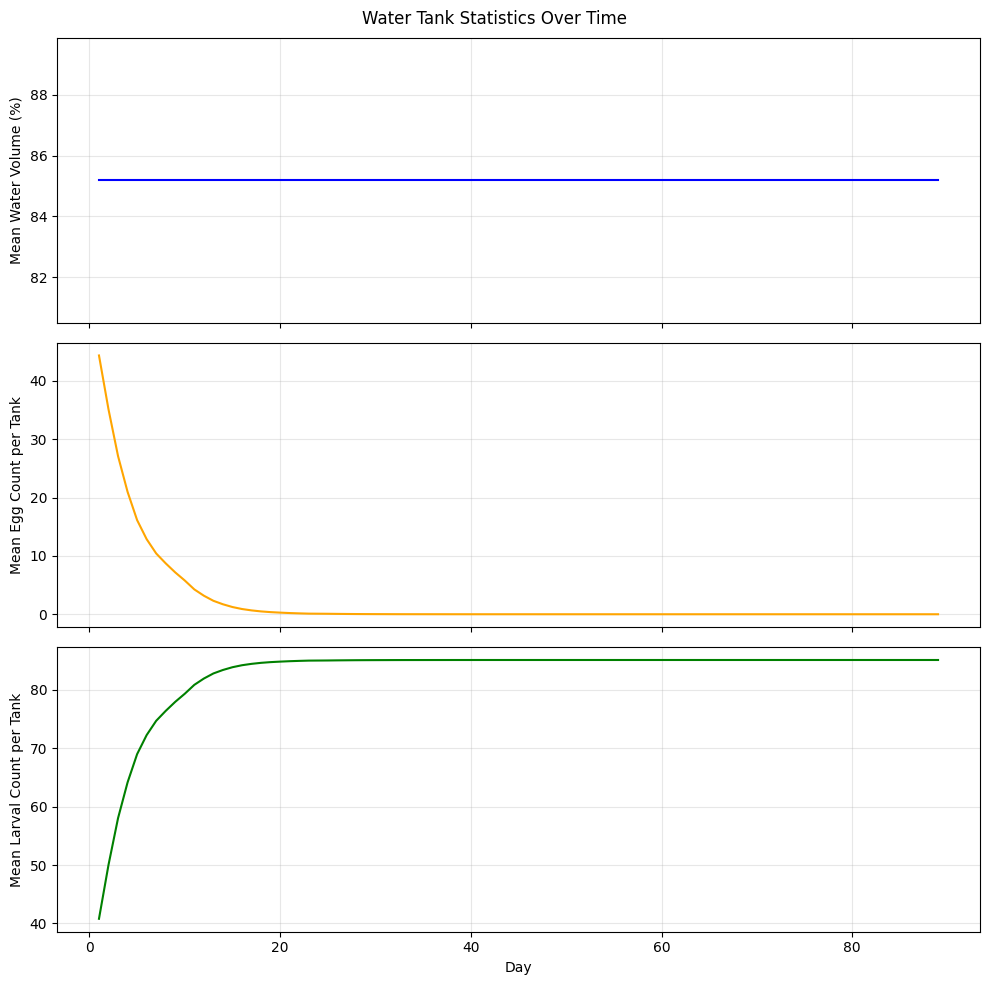

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
axes[0].plot(daily_inert['Day'], daily_inert['MeanWaterVolume'], color='blue')
axes[0].set_ylabel('Mean Water Volume (%)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(daily_inert['Day'], daily_inert['TotalEggs'] / daily_inert['TankCount'].clip(lower=1), color='orange')
axes[1].set_ylabel('Mean Egg Count per Tank')
axes[1].grid(True, alpha=0.3)

axes[2].plot(daily_inert['Day'], daily_inert['TotalLarvae'] / daily_inert['TankCount'].clip(lower=1), color='green')
axes[2].set_ylabel('Mean Larval Count per Tank')
axes[2].set_xlabel('Day')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Water Tank Statistics Over Time')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/tank_stats.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Environmental Correlation (Dynamic)

Plot each configured environment variable on its own y‑axis (twinx) if multiple, or separate subplots.

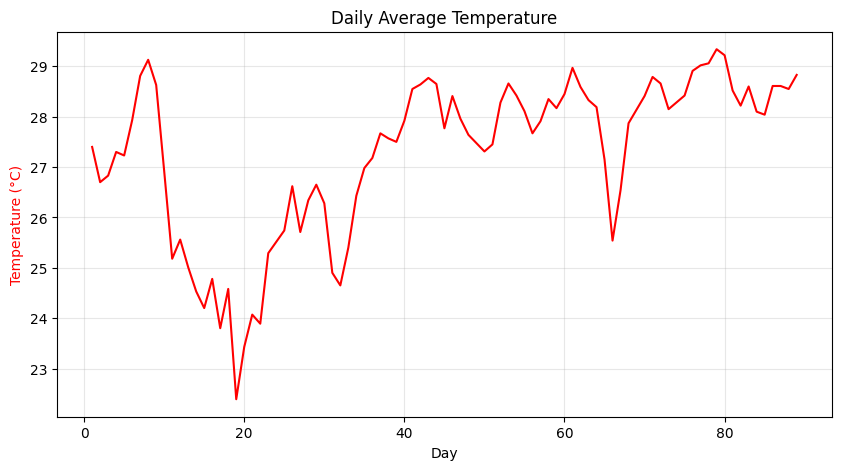

Correlation adult count vs Temperature: r=-0.619 (p=2.145e-10)


In [15]:
if len(ENV_VARS) == 1:
    # Single variable – simple plot
    col, disp, unit, _, _ = ENV_VARS[0]
    mean_col = f'Mean{disp}'
    plt.figure(figsize=(10,5))
    plt.plot(daily_living['Day'], daily_living[mean_col], color='red')
    plt.ylabel(f'{disp} ({unit})', color='red')
    plt.xlabel('Day')
    plt.title(f'Daily Average {disp}')
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{OUTPUT_DIR}/environment.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    # Multiple variables – create twin axes
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.set_xlabel('Day')
    axes = [ax1]
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    for i, (col, disp, unit, _, _) in enumerate(ENV_VARS):
        mean_col = f'Mean{disp}'
        if i == 0:
            ax = ax1
            ax.set_ylabel(f'{disp} ({unit})', color=colors[i])
            ax.tick_params(axis='y', labelcolor=colors[i])
        else:
            ax = ax1.twinx()
            ax.set_ylabel(f'{disp} ({unit})', color=colors[i])
            ax.tick_params(axis='y', labelcolor=colors[i])
            axes.append(ax)
        ax.plot(daily_living['Day'], daily_living[mean_col], color=colors[i], label=disp)
    fig.legend(loc='upper right')
    plt.title('Daily Average Environmental Conditions')
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{OUTPUT_DIR}/environment.png', dpi=300, bbox_inches='tight')
    plt.show()

# Correlation with adult counts (for each variable)
adult_series = daily_living['AdultCount'].values
for col, disp, unit, _, _ in ENV_VARS:
    mean_col = f'Mean{disp}'
    var_series = daily_living[mean_col].values
    corr, p = pearsonr(adult_series, var_series)
    print(f"Correlation adult count vs {disp}: r={corr:.3f} (p={p:.3e})")

## 5. Temporal Autocorrelation & Cross‑correlation (with temperature if available)

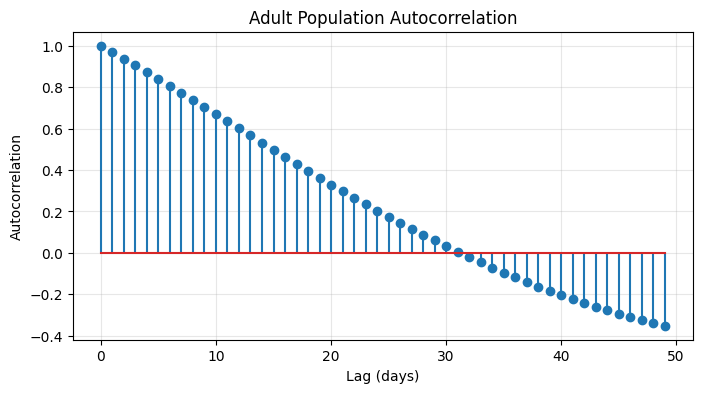

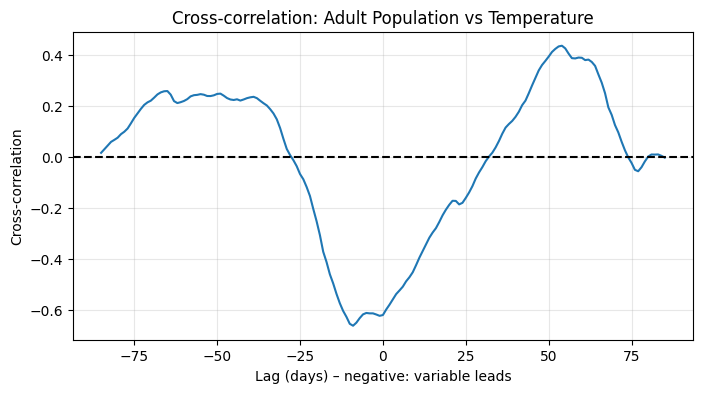

In [16]:
adult_vals = daily_living['AdultCount'].values
lags = correlation_lags(len(adult_vals), len(adult_vals))
acf = correlate(adult_vals - adult_vals.mean(), adult_vals - adult_vals.mean(), mode='full')
acf = acf / acf[len(acf)//2]

plt.figure(figsize=(8,4))
plt.stem(lags[len(lags)//2: len(lags)//2+50], acf[len(acf)//2: len(acf)//2+50])
plt.xlabel('Lag (days)')
plt.ylabel('Autocorrelation')
plt.title('Adult Population Autocorrelation')
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/autocorrelation.png', dpi=300, bbox_inches='tight')
plt.show()

# Cross‑correlation with the first environment variable (typically temperature)
if ENV_VARS:
    first_var = ENV_VARS[0]
    var_vals = daily_living[f'Mean{first_var[1]}'].values
    ccf = correlate(adult_vals - adult_vals.mean(), var_vals - var_vals.mean(), mode='full')
    ccf = ccf / (len(adult_vals) * adult_vals.std() * var_vals.std())
    lag_days = lags
    plt.figure(figsize=(8,4))
    plt.plot(lag_days, ccf)
    plt.axhline(0, color='black', linestyle='--')
    plt.xlabel('Lag (days) – negative: variable leads')
    plt.ylabel('Cross‑correlation')
    plt.title(f'Cross‑correlation: Adult Population vs {first_var[1]}')
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{OUTPUT_DIR}/crosscorrelation.png', dpi=300, bbox_inches='tight')
    plt.show()

## 6. Spatial Analysis (Memory‑Efficient, Full Data)

We first determine which ticks actually contain adult mosquitoes (by scanning the file once). Then we select three representative ticks (first, middle, last) for detailed spatial maps.

**Functions:**
- `get_ticks_with_adults`: scans file to collect ticks that have at least one adult.
- `get_points_for_tick`: reads all points for a given tick and agent type (capped at `MAX_SPATIAL_POINTS_PER_TICK` to avoid memory overflow).

In [17]:
def get_ticks_with_adults(filepath, max_ticks=100):
    """Return sorted list of ticks that contain at least one adult mosquito."""
    ticks = set()
    for chunk in pd.read_csv(filepath, chunksize=CHUNKSIZE, usecols=['TickCount', 'AgentType', 'Stage'], low_memory=False):
        adults = chunk[(chunk['AgentType'] == 'LivingAgent') & (chunk['Stage'] == 'ADULT')]
        ticks.update(adults['TickCount'].unique())
        if len(ticks) >= max_ticks:
            break
    return sorted(ticks)

def get_points_for_tick(filepath, tick, agent_type, stage=None, max_points=MAX_SPATIAL_POINTS_PER_TICK):
    """
    Read points (X, Y) for a given tick and agent type.
    If the number of points exceeds max_points, it is randomly sampled down.
    """
    usecols = ['TickCount', 'AgentType', 'X', 'Y', 'Stage']
    sampled_rows = []
    total_found = 0
    for chunk in pd.read_csv(filepath, chunksize=CHUNKSIZE, usecols=usecols, low_memory=False):
        mask = (chunk['TickCount'] == tick) & (chunk['AgentType'] == agent_type)
        if stage is not None:
            mask = mask & (chunk['Stage'] == stage)
        sub = chunk.loc[mask, ['X', 'Y']]
        total_found += len(sub)
        if not sub.empty:
            sampled_rows.append(sub)
        if total_found >= max_points:
            break
    if not sampled_rows:
        return pd.DataFrame()
    result = pd.concat(sampled_rows, ignore_index=True)
    if len(result) > max_points:
        result = result.sample(n=max_points, random_state=42)
        print(f"  Warning: tick {tick} had {total_found} points, downsampled to {max_points} for memory.")
    return result

# Find ticks with adults
ticks_with_adults = get_ticks_with_adults(INPUT_FILE, max_ticks=100)
print(f"Found {len(ticks_with_adults)} ticks with adult mosquitoes. First few: {ticks_with_adults[:5]}")

if len(ticks_with_adults) >= 3:
    selected_ticks = [ticks_with_adults[0], ticks_with_adults[len(ticks_with_adults)//2], ticks_with_adults[-1]]
else:
    # fallback: use first, middle, last from daily aggregation
    all_ticks = (daily_living['Day'] * TICKS_PER_DAY).astype(int).values
    selected_ticks = [all_ticks[0], all_ticks[len(all_ticks)//2], all_ticks[-1]]

print(f"Selected ticks for spatial plots: {selected_ticks}")

Found 86 ticks with adult mosquitoes. First few: [np.int64(100), np.int64(200), np.int64(300), np.int64(400), np.int64(500)]
Selected ticks for spatial plots: [np.int64(100), np.int64(4400), np.int64(8600)]


### 6.1 Adult Density Heatmap + Tank Locations
For each selected tick, we plot a KDE heatmap of adult mosquitoes, overlay tank positions (x markers), and adult points (scatter). Basemap is added if available.

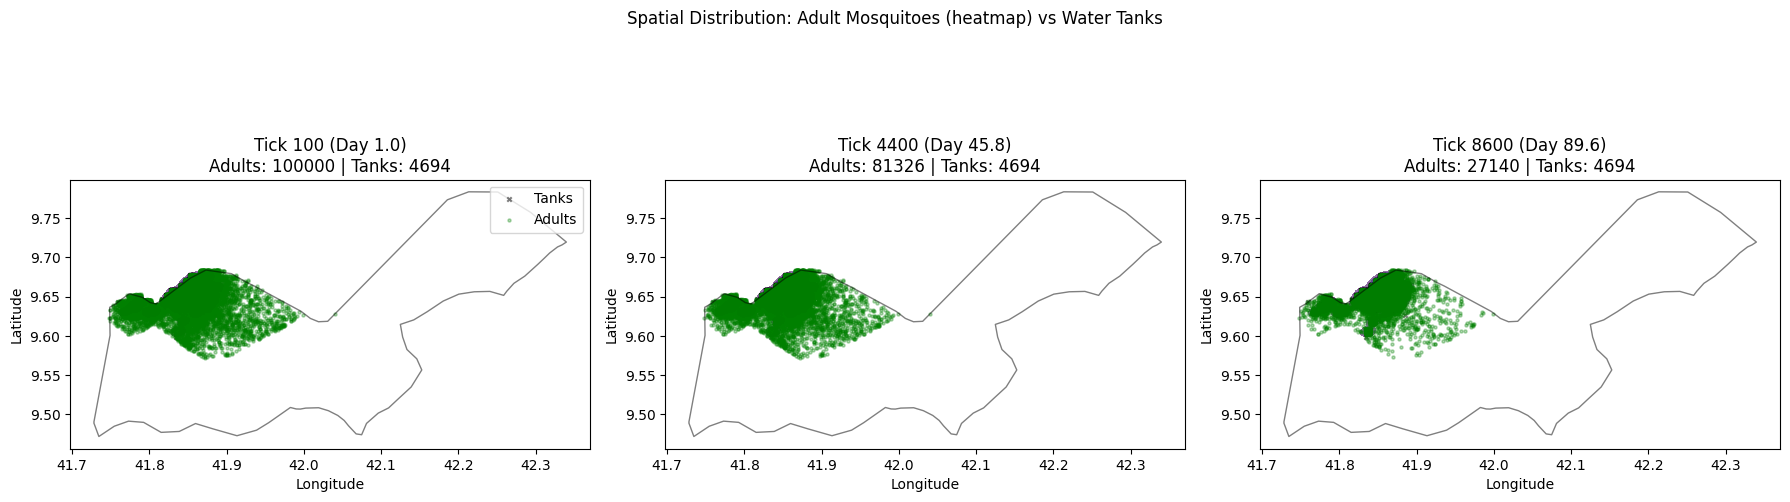

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, tick in zip(axes, selected_ticks):
    adults = get_points_for_tick(INPUT_FILE, tick, 'LivingAgent', stage='ADULT')
    tanks = get_points_for_tick(INPUT_FILE, tick, 'InertAgent')
    
    if study_area is not None:
        study_area.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.5)
    
    if len(adults) > 5:
        sns.kdeplot(data=adults, x='X', y='Y', fill=True, cmap='viridis', alpha=0.6, ax=ax)
    if not tanks.empty:
        ax.scatter(tanks['X'], tanks['Y'], s=10, marker='x', color='black', alpha=0.5, label='Tanks')
    if not adults.empty:
        ax.scatter(adults['X'], adults['Y'], s=5, color='green', alpha=0.3, label='Adults')
    
    ax.set_title(f'Tick {tick} (Day {tick/TICKS_PER_DAY:.1f})\nAdults: {len(adults)} | Tanks: {len(tanks)}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    if ax == axes[0]:
        ax.legend()

plt.suptitle('Spatial Distribution: Adult Mosquitoes (heatmap) vs Water Tanks')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/spatial_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.2 Proximity Analysis (Adult → Nearest Tank) Over Time

We sample a subset of ticks (at most 50) and for each compute the mean and median Euclidean distance (in degrees) from each adult to its nearest tank. Convert degrees to kilometres (multiply by ~111).

In [ ]:
if len(ticks_with_adults) > 50:
    step = len(ticks_with_adults) // 50
    ticks_to_analyze = ticks_with_adults[::step]
else:
    ticks_to_analyze = ticks_with_adults[::max(1, len(ticks_with_adults)//20)]

print(f"Analyzing {len(ticks_to_analyze)} ticks for proximity...")

proximity_results = []
for tick in ticks_to_analyze:
    adults = get_points_for_tick(INPUT_FILE, tick, 'LivingAgent', stage='ADULT', max_points=MAX_SPATIAL_POINTS_PER_TICK)
    tanks = get_points_for_tick(INPUT_FILE, tick, 'InertAgent', max_points=MAX_SPATIAL_POINTS_PER_TICK)
    if len(adults) > 10 and len(tanks) > 5:
        tree = cKDTree(tanks[['X','Y']].values)
        dists, _ = tree.query(adults[['X','Y']].values)
        proximity_results.append({
            'Tick': tick,
            'Day': tick / TICKS_PER_DAY,
            'MeanDist_deg': np.mean(dists),
            'MedianDist_deg': np.median(dists),
            'N_adults': len(adults),
            'N_tanks': len(tanks)
        })
    else:
        print(f"  Skipping tick {tick}: adults={len(adults)}, tanks={len(tanks)}")

prox_df = pd.DataFrame(proximity_results)
if not prox_df.empty:
    print(f"Proximity computed for {len(prox_df)} ticks.")
    plt.figure(figsize=(8,5))
    plt.plot(prox_df['Day'], prox_df['MeanDist_deg']*111, marker='o', linestyle='-', label='Mean distance (km)')
    plt.fill_between(prox_df['Day'], 
                     (prox_df['MeanDist_deg'] - prox_df['MedianDist_deg'])*111,
                     (prox_df['MeanDist_deg'] + prox_df['MedianDist_deg'])*111, alpha=0.2)
    plt.xlabel('Day')
    plt.ylabel('Distance to nearest tank (km)')
    plt.title('Adult Mosquito Proximity to Breeding Sites')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(f'{OUTPUT_DIR}/proximity.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Not enough data for proximity analysis (need at least 10 adults and 5 tanks per tick).")

Analyzing 86 ticks for proximity...


### 6.3 Hotspot (LISA) Map – Getis‑Ord Gi* style

For the last tick, we count how many adult mosquitoes lie within a radius (0.0005° ≈ 55 m) of each adult. This gives a simple hotspot indicator.

In [ ]:
def get_hotspots(adults, radius_deg=0.0005):
    if len(adults) < 2:
        return np.zeros(len(adults))
    tree = cKDTree(adults[['X','Y']].values)
    neighbors = tree.query_ball_tree(tree, radius_deg)
    return np.array([len(n) for n in neighbors])

last_tick = ticks_with_adults[-1]
adults_last = get_points_for_tick(INPUT_FILE, last_tick, 'LivingAgent', stage='ADULT')
if len(adults_last) > 0:
    hotspots = get_hotspots(adults_last, radius_deg=0.0005)
    plt.figure(figsize=(8,6))
    if study_area is not None:
        study_area.boundary.plot(ax=plt.gca(), color='black', linewidth=1, alpha=0.5)
    sc = plt.scatter(adults_last['X'], adults_last['Y'], c=hotspots, cmap='hot', s=10, alpha=0.7)
    plt.colorbar(sc, label='Number of adults within 55m')
    plt.title(f'Adult Hotspots (Tick {last_tick}, Day {last_tick/TICKS_PER_DAY:.1f})')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.savefig(f'{OUTPUT_DIR}/hotspots.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No adults at last tick, skipping hotspot map.")

### 6.4 Tank Occupancy Heatmap (Eggs + Larvae per Tank)

For the last tick, plot each water tank coloured by the total number of immature stages (eggs + larvae) it contains.

In [ ]:
last_tick_inert = ticks_with_adults[-1]  # or inert's last tick; we can reuse
tanks_last = get_points_for_tick(INPUT_FILE, last_tick_inert, 'InertAgent')
if not tanks_last.empty:
    # Need to also read EggCount and LarvaCount for the same tick – we'll use a separate function
    usecols = ['TickCount', 'AgentType', 'X', 'Y', 'EggCount', 'LarvaCount']
    rows = []
    for chunk in pd.read_csv(INPUT_FILE, chunksize=CHUNKSIZE, usecols=usecols, low_memory=False):
        mask = (chunk['TickCount'] == last_tick_inert) & (chunk['AgentType'] == 'InertAgent')
        sub = chunk.loc[mask, ['X', 'Y', 'EggCount', 'LarvaCount']]
        if not sub.empty:
            rows.append(sub)
            if len(rows) * CHUNKSIZE > MAX_SPATIAL_POINTS_PER_TICK:
                break
    if rows:
        tanks_full = pd.concat(rows, ignore_index=True)
        tanks_full['Immature'] = tanks_full['EggCount'] + tanks_full['LarvaCount']
        plt.figure(figsize=(10,8))
        if study_area is not None:
            study_area.boundary.plot(ax=plt.gca(), color='black', linewidth=1, alpha=0.5)
        sc = plt.scatter(tanks_full['X'], tanks_full['Y'], c=tanks_full['Immature'], cmap='plasma', s=20, alpha=0.7)
        plt.colorbar(sc, label='Eggs + Larvae per tank')
        plt.title(f'Breeding Site Load (Tick {last_tick_inert}, Day {last_tick_inert/TICKS_PER_DAY:.1f})')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.savefig(f'{OUTPUT_DIR}/tank_load.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("No tank data for the last tick.")
else:
    print("No tank data for the last tick.")

## 7. Validation: Metzler Matrix Predicted Growth Rate

Compare the observed daily log growth rate of adults with the theoretical dominant eigenvalue (λmax) of the Metzler matrix, computed from daily mean temperature (if available) and a fixed livestock density. If temperature is not configured, this section is skipped.

In [ ]:
# Only run if we have temperature data
temp_var = None
for col, disp, unit, _, _ in ENV_VARS:
    if 'temp' in col.lower() or disp.lower() == 'temperature':
        temp_var = (col, disp)
        break

if temp_var is not None:
    def metzler_lambda_max(T_C, livestock_density, params):
        a, b, Tmax, c = params['fecundity_a'], params['fecundity_b'], params['fecundity_Tmax'], params['fecundity_c']
        term1 = a * np.exp(b * T_C)
        term2 = np.exp(b * Tmax - ((Tmax - T_C)/c)**2)
        F = max(0, term1 - term2)
        
        dE = max(0, params['egg_dev_a']*T_C**2 + params['egg_dev_b']*T_C + params['egg_dev_c'])
        dL = max(0, params['larva_dev_a']*T_C**2 + params['larva_dev_b']*T_C + params['larva_dev_c'])
        dP = max(0, params['pupa_dev_a']*T_C**2 + params['pupa_dev_b']*T_C + params['pupa_dev_c'])
        muA = max(0, params['adult_mort_a']*T_C**2 + params['adult_mort_b']*T_C + params['adult_mort_c'])
        
        SE = params['egg_survival_amp'] * np.exp(-0.5 * ((T_C - params['egg_survival_mean'])/params['egg_survival_sigma'])**2)
        SL = params['larva_survival_amp'] * np.exp(-0.5 * ((T_C - params['larva_survival_mean'])/params['larva_survival_sigma'])**2)
        SP = params['pupa_survival_amp'] * np.exp(-0.5 * ((T_C - params['pupa_survival_mean'])/params['pupa_survival_sigma'])**2)
        
        K = 1 + np.log1p(max(0, livestock_density))
        
        M = np.array([
            [-dE, 0, 0, F * K],
            [SE*dE, -dL, 0, 0],
            [0, SL*dL, -dP, 0],
            [0, 0, SP*dP, -muA]
        ])
        v = np.ones(4)
        for _ in range(50):
            v = M @ v
            v = v / np.linalg.norm(v)
        lambda_max = (v @ (M @ v)) / (v @ v)
        return lambda_max

    params = {
        'fecundity_a': 0.378, 'fecundity_b': 0.173, 'fecundity_Tmax': 40.0, 'fecundity_c': 2.97,
        'egg_dev_a': -0.0009, 'egg_dev_b': 0.048, 'egg_dev_c': -0.345,
        'larva_dev_a': -0.0007, 'larva_dev_b': 0.039, 'larva_dev_c': -0.32,
        'pupa_dev_a': -0.0005, 'pupa_dev_b': 0.026, 'pupa_dev_c': -0.2,
        'egg_survival_amp': 1.01, 'egg_survival_mean': 24.5, 'egg_survival_sigma': 4.8,
        'larva_survival_amp': 0.95, 'larva_survival_mean': 27.0, 'larva_survival_sigma': 3.5,
        'pupa_survival_amp': 0.93, 'pupa_survival_mean': 26.8, 'pupa_survival_sigma': 3.8,
        'adult_mort_a': -0.00065, 'adult_mort_b': 0.0364, 'adult_mort_c': -0.4882
    }

    livestock_density = 0.1  # default; could be read from population layer if needed
    mean_temp_col = f'Mean{temp_var[1]}'
    lambda_vals = [metzler_lambda_max(temp, livestock_density, params) for temp in daily_living[mean_temp_col]]

    adult_log = np.log(daily_living['AdultCount'] + 1)
    obs_growth = np.diff(adult_log)
    days_obs = daily_living['Day'].values[1:]
    lambda_series = np.array(lambda_vals)[1:]

    plt.figure(figsize=(10,5))
    plt.plot(days_obs, obs_growth, label='Observed daily log growth rate', alpha=0.7)
    plt.plot(days_obs, lambda_series, label='Predicted λmax (Metzler)', linestyle='--', color='red')
    plt.xlabel('Day')
    plt.ylabel('Rate (1/day)')
    plt.title('Observed vs Predicted Population Growth Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{OUTPUT_DIR}/growth_validation.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No temperature variable configured – skipping Metzler validation.")

## 8. Stage Duration Estimation (Cross‑correlation of Stage Counts)

The time lag between the peak of larvae and the peak of pupae gives an estimate of larval duration; similarly for pupae → adults.

In [ ]:
larvae_vals = daily_living['LarvaCount'].values
pupae_vals = daily_living['PupaCount'].values
adult_vals2 = daily_living['AdultCount'].values

ccf_lp = correlate(larvae_vals - larvae_vals.mean(), pupae_vals - pupae_vals.mean(), mode='full')
lags = correlation_lags(len(larvae_vals), len(pupae_vals))
lag_lp = lags[np.argmax(ccf_lp)]
print(f"Estimated larval duration: {lag_lp:.2f} days")

ccf_pa = correlate(pupae_vals - pupae_vals.mean(), adult_vals2 - adult_vals2.mean(), mode='full')
lag_pa = lags[np.argmax(ccf_pa)]
print(f"Estimated pupal duration: {lag_pa:.2f} days")

## 9. Export Tidy Data for Further Use

- Daily summary (all aggregated variables)
- A small sample (10 000 rows) of the raw data for quick inspection

In [ ]:
daily_summary = pd.merge(daily_living, daily_inert, on='Day', how='outer')
daily_summary.to_csv(f'{OUTPUT_DIR}/daily_summary.csv', index=False)

# Sample of raw data (first 10k rows)
sample_df = pd.read_csv(INPUT_FILE, nrows=10000)
sample_df.to_csv(f'{OUTPUT_DIR}/living_sample.csv', index=False)

print(f"Summaries saved to {OUTPUT_DIR}/")
print("Files: daily_summary.csv, living_sample.csv")

In [ ]:
print("Analysis complete. All figures saved.")